In [15]:
import numpy as np
import pandas as pd
from matplotlib import cm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
df = pd.read_csv('data.csv')
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


 ## Ответы

* Предобработка данных для случайного леса отличается от обработки данных для лин рег тем, что в случае с деревьями масштабирование не требуется
* Выборка была разделена с помощью train_test_split
* При кросс-валидации выборку обычно делят на 5 фолдов
* Выборку можно разделить вручную: **train**, **validation** (для подбора гиперпараметров) и **test**

In [16]:
size_map = {'Diesel' : 1, 'Petrol' : 2, 'CNG' : 3}
df['nFuel_Type'] = df['Fuel_Type'].map(size_map)
df = df.drop(columns=['Fuel_Type'])

size_map = {'Blue' : 1, 'Silver' : 2, 'Black' : 3, 'White' : 4, 'Grey' : 5, 'Red' : 6, 'Green' : 7, 'Yellow' : 8, 'Violet' : 9, 'Beige' : 10}
df['nColor'] = df['Color'].map(size_map)
df = df.drop(columns=['Color'])
df = df.drop(columns = ['Id', 'Model'])

In [17]:
df.head()

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,...,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,nFuel_Type,nColor
0,13500,23,10,2002,46986,90,1,0,2000,3,...,0,0,0,1,0,0,0,0,1,1
1,13750,23,10,2002,72937,90,1,0,2000,3,...,0,0,0,1,0,0,0,0,1,2
2,13950,24,9,2002,41711,90,1,0,2000,3,...,0,0,0,1,0,0,0,0,1,1
3,14950,26,7,2002,48000,90,0,0,2000,3,...,0,0,0,1,0,0,0,0,1,3
4,13750,30,3,2002,38500,90,0,0,2000,3,...,0,1,0,1,0,0,0,0,1,3


In [18]:
X = np.array(df.iloc[:, 1:37])
y = np.array(df.iloc[:, 0])
print(y)

[13500 13750 13950 ...  8500  7250  6950]


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

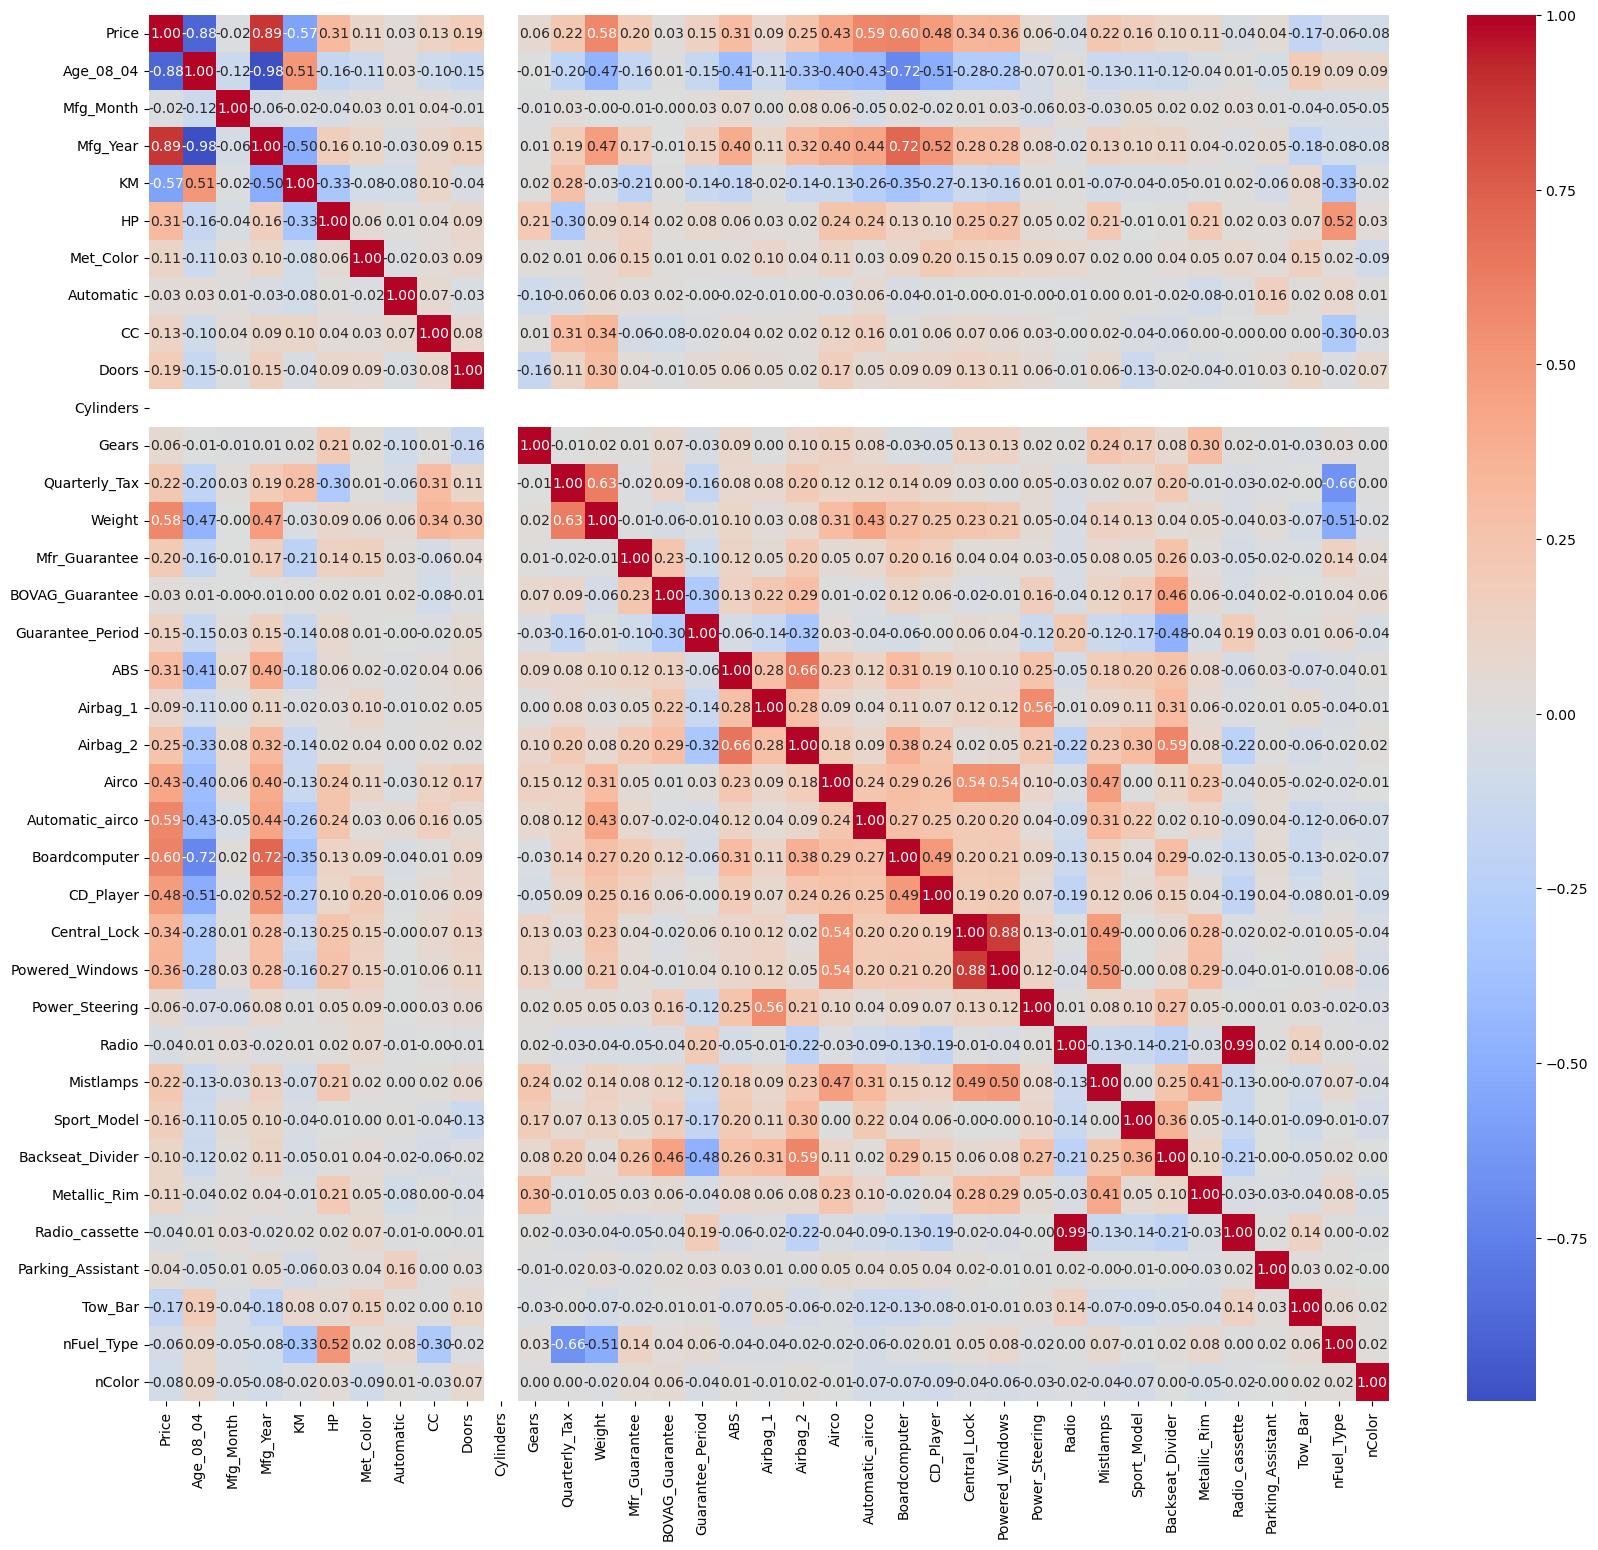

In [20]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, 
            annot=True,      
            cmap='coolwarm', 
            fmt=".2f",      
            center=0)   
plt.show()

In [21]:
rfr = RandomForestRegressor(
    n_estimators=200,   
    max_depth=15,     
    min_samples_split=5,  
    n_jobs=-1,            
    random_state=42,
    criterion='squared_error'
)
rfr.fit(X_train, y_train)
rfr_pred = rfr.predict(X_test)

In [22]:
rfr_r2 = r2_score(y_test, rfr_pred)
print(rfr_r2)

0.9237659026463989


In [23]:
dtr = DecisionTreeRegressor(max_depth = 15, min_samples_split=5, criterion = 'squared_error')
dtr.fit(X_train, y_train)
dtr_pred = dtr.predict(X_test)

In [24]:
dtr_r2 = r2_score(y_test, dtr_pred)
print(dtr_r2)

0.8615842455385945


### Вопросы для анализа:
1) **Сравнение скорости:** сравните, какая модель обучалась быстрее. 
2) **Можно ли добиться одинаковой или близкой к одинаковой скорости?**
3) **Сравнение качества:** сравните результаты одного дерева и случайного леса.


### Оценка качества и сравнение моделей
Линейная регрессия в пайплайне с PolynomialFeatures при лучших параметрах после GridSearchCV даёт **R2 = 0.84**, а RandomForestRegressor даёт R2 = 0.92**

### Ответы:
1) Быстрее обучалось одно дерево
2) Можно, если уменьшить количество деревьев в RandomForestRegressor
3) Лес обучился лучше, чем одно дерево

